In [1]:
# Core libraries
import numpy as np
import os

# Image processing
import cv2

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Model utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import zipfile
import os

zip_path = r"C:\Users\HP\Downloads\NLP\face emotion datset.zip"
extract_path = r"C:\Users\HP\Downloads\NLP\face emotion datset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
data_dir =  r"C:\Users\HP\Downloads\NLP\face emotion datset"
print(os.listdir(data_dir))

['test', 'train']


In [ ]:
def extract_zip(zip_path, extract_path):
    import zipfile, os
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted {zip_path} to {extract_path}")

extract_zip("face emotion datset.zip", "face emotion datset")

In [4]:
# 1. Load the original dataset
import tensorflow as tf
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\HP\Downloads\NLP\face emotion datset",
    batch_size=32,
    image_size=(224, 224)
)

# 2. CAPTURE CLASS NAMES HERE (while they still exist)
class_names = raw_train_ds.class_names
print(f"✅ Detected emotion classes: {class_names}")

# 3. Now apply performance optimizations (Prefetch, Cache)
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 35887 files belonging to 2 classes.
✅ Detected emotion classes: ['test', 'train']


In [5]:
import os
import tensorflow as tf

PATH = r"C:\Users\HP\Downloads\NLP\face emotion datset" 

# 2. Define your global constants
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

# 3. Now the loading code will work
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'test'), # Often called 'test' or 'val' in datasets
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Detected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
# 1. Check dataset info
print(f"Number of batches in training: {len(train_ds)}")
print(f"Number of batches in validation: {len(val_ds)}")

Number of batches in training: 898
Number of batches in validation: 225


Unique labels in this batch: [0 2 3 4 5 6]


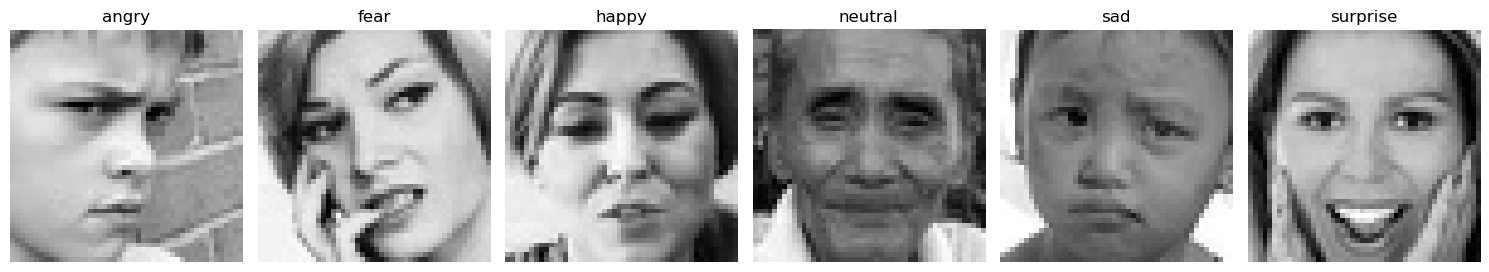

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Manually pull ONE batch from the training dataset
for images, labels in train_ds.take(1):
    
    # 2. Convert One-Hot (2D) to Integers (1D)
    label_indices = tf.argmax(labels, axis=1).numpy()

    # 3. Find unique values using NumPy
    unique_labels = np.unique(label_indices)
    print(f"Unique labels in this batch: {unique_labels}")

    # 4. Get the first occurrence of each unique label for visualization
    unique_vals, unique_indices = np.unique(label_indices, return_index=True)

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(unique_indices):
        plt.subplot(1, len(unique_indices), i + 1)
        plt.imshow(images[idx].numpy().astype("uint8").squeeze(), cmap='gray')
        plt.title(f"{class_names[unique_vals[i]]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [9]:
# Show the first 5 labels to verify format
print("Sample Labels (One-Hot):")
print(labels[:5].numpy())

# Show the corresponding class indices
print("Sample Labels (Indices):")
print(tf.argmax(labels[:5], axis=1).numpy())

Sample Labels (One-Hot):
[[0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]
Sample Labels (Indices):
[2 6 2 2 6]


In [10]:
import os
import tensorflow as tf

# 1. Define your path (Ensure this points to your train folder)
PATH = r"C:\Users\HP\Downloads\NLP\face emotion datset\train"

# 2. Create the raw dataset variable that was missing
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    image_size=(48, 48), # Use the size you used in Phase 1
    batch_size=32,
    color_mode='grayscale',
    label_mode='categorical'
)

# 3. NOW run the code that was crashing
class_names = raw_train_ds.class_names
print(f"✅ Detected classes: {class_names}")

# Optimization
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 28709 files belonging to 7 classes.
✅ Detected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
import numpy as np

# Iterate through the labels in the dataset
labels_list = []
for images, labels in raw_train_ds: # Use raw_train_ds, not the prefetched one
    labels_list.extend(labels.numpy())

# Count occurrences
unique, counts = np.unique(labels_list, return_counts=True)
distribution = dict(zip([class_names[i] for i in unique], counts))

print("✅ Counts inside Dataset object:", distribution)

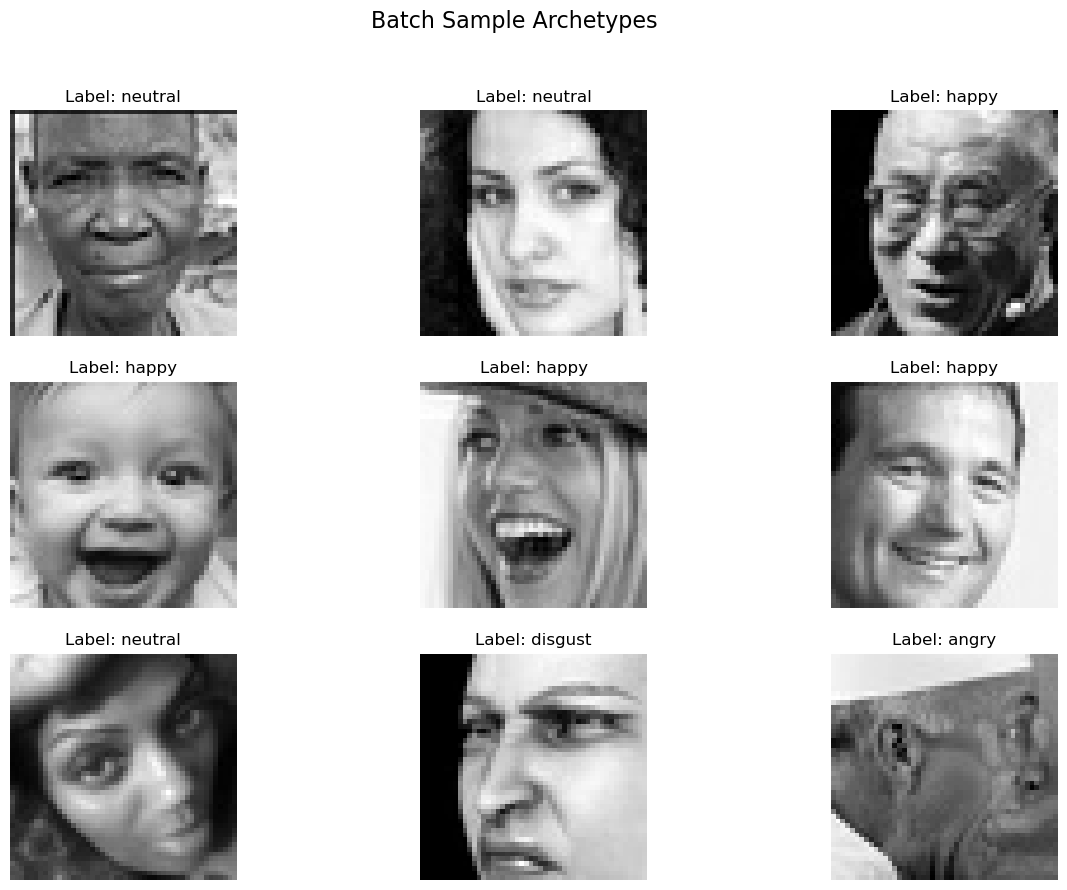

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sample_batch(dataset, class_names):
    # Get one batch of 32 images and labels
    for images, labels in dataset.take(1):
        plt.figure(figsize=(15, 10))
        # Plot the first 9 images from the batch
        for i in range(9):
            plt.subplot(3, 3, i + 1)
            # Squeeze is used in case of grayscale (48, 48, 1) -> (48, 48)
            img = images[i].numpy().astype("uint8").squeeze()
            plt.imshow(img, cmap='gray')
            
            # Use argmax to handle categorical labels
            label_idx = np.argmax(labels[i])
            plt.title(f"Label: {class_names[label_idx]}")
            plt.axis("off")
        
        plt.suptitle("Batch Sample Archetypes", fontsize=16)
        plt.show()

# Run the fixed function
plot_sample_batch(train_ds, class_names)

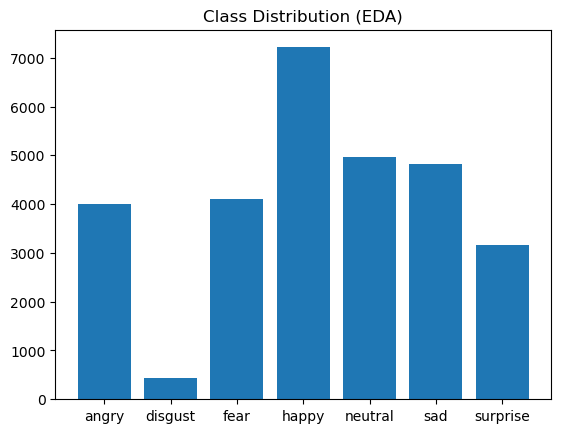

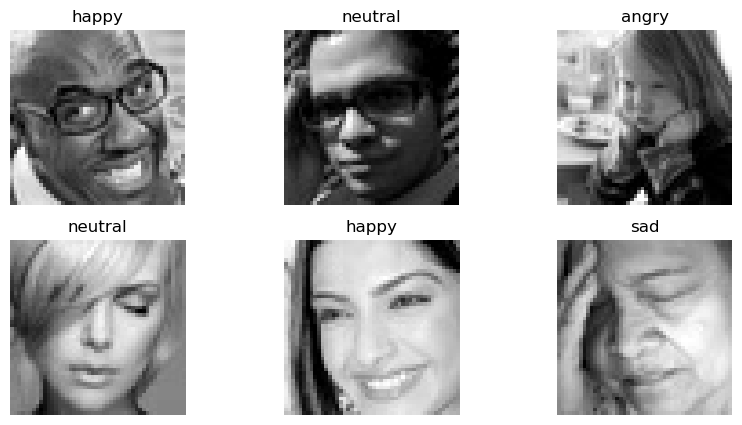

In [13]:
# Check class distribution
labels = []
for _, label_batch in train_ds:
    labels.extend(np.argmax(label_batch, axis=1))

unique, counts = np.unique(labels, return_counts=True)
plt.bar(class_names, counts)
plt.title("Class Distribution (EDA)")
plt.show()

# Visualize Samples
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap='gray')
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")

Columns found: ['width', 'height', 'class']


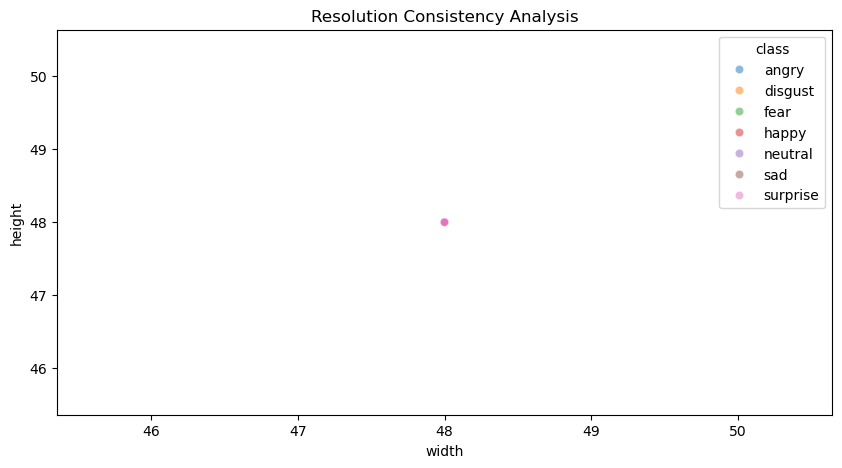

In [14]:
import os
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_image_metadata(root_path):
    data = []
    # Standard emotion folders
    for emotion in os.listdir(root_path):
        emotion_path = os.path.join(root_path, emotion)
        if os.path.isdir(emotion_path):
            for img_name in os.listdir(emotion_path):
                try:
                    img_path = os.path.join(emotion_path, img_name)
                    with Image.open(img_path) as img:
                        # We use lowercase 'width' and 'height' to match your plot call
                        w, h = img.size
                        data.append({'width': w, 'height': h, 'class': emotion})
                except:
                    continue # Skip files that aren't valid images
    return pd.DataFrame(data)

# Update this path to your exact folder
path = r"C:\Users\HP\Downloads\NLP\face emotion datset\train"
df_meta = get_image_metadata(path)

# --- DEBUG CHECK ---
if df_meta.empty:
    print("Error: No images found! Check your path.")
else:
    print("Columns found:", df_meta.columns.tolist())
    
    plt.figure(figsize=(10, 5))
    # Alpha helps see overlapping points (since most FER images are 48x48)
    sns.scatterplot(data=df_meta, x='width', y='height', hue='class', alpha=0.5)
    plt.title("Resolution Consistency Analysis")
    plt.show()

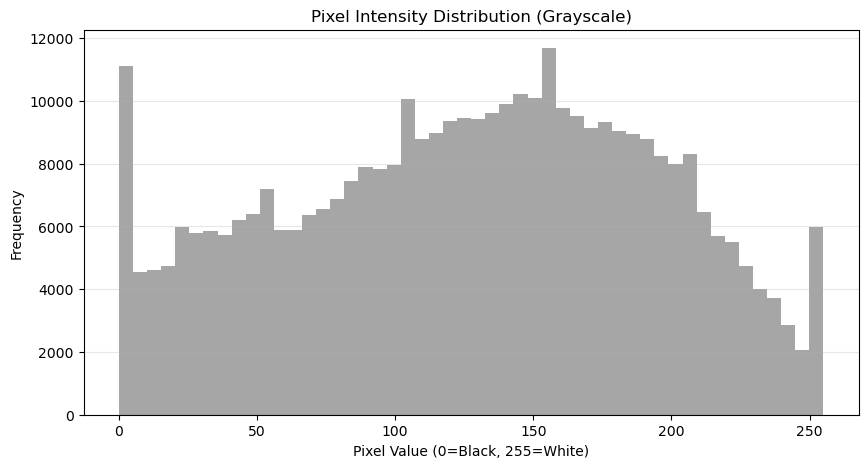

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_intensity_distribution(dataset):
    intensities = []
    for images, _ in dataset.take(5):
        # images shape is (batch_size, 48, 48, 1)
        # We flatten all pixels into a single list
        batch_pixels = images.numpy().flatten()
        intensities.extend(batch_pixels)
    
    plt.figure(figsize=(10, 5))
    plt.hist(intensities, bins=50, color='gray', alpha=0.7)
    plt.title("Pixel Intensity Distribution (Grayscale)")
    plt.xlabel("Pixel Value (0=Black, 255=White)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Call the fixed function
plot_intensity_distribution(train_ds)

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ultimate_model(num_classes=7):
    # 1. Base Model optimized for higher resolution
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3), # Increased resolution
        include_top=False, 
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False 

    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),
        
        # STEP A: Upscale the image to give the model more 'room' to see features
        layers.Resizing(96, 96), 
        
        # STEP B: MobileNetV2 Normalization (-1 to 1)
        layers.Rescaling(1./127.5, offset=-1),
        
        # STEP C: Grayscale to RGB
        layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
        
        base_model,
        
        # STEP D: Heavy Regularization to stop overfitting
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5), 
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # STEP E: Label Smoothing helps with 'Neutral' confusion
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    return model, base_model

model, base_model = build_ultimate_model()

In [17]:
import numpy as np
from sklearn.utils import class_weight

# 1. Extract labels from your training dataset
y_train = []
for images, labels in train_ds:
    # Convert one-hot back to integers
    y_train.extend(np.argmax(labels.numpy(), axis=1))

# 2. Calculate weights using sklearn
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# 3. Create the dictionary for model.fit()
dict_weights = dict(enumerate(weights))

print("Class weights calculated successfully:")
print(dict_weights)

Class weights calculated successfully:
{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. DEFINE AND BUILD (Run this cell first)
def build_model():
    # We define base_model separately so we can reference it later
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3), 
        include_top=False, 
        weights='imagenet',
        pooling='avg'
    )
    base_model.trainable = False # Start frozen

    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),
        layers.Resizing(96, 96),
        layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
        base_model,
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])
    
    return model, base_model

# Initialize both variables globally
model, base_model = build_model()

In [19]:
# UNFREEZE for Phase 2
import os
import tensorflow as tf

# 1. Re-define the PATH (Adjust this to your actual folder)
PATH = r"C:\Users\HP\Downloads\NLP\face emotion datset" 
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

# 2. Define train_ds
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical'
)

# 3. Define val_ds (This is what was missing!)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'test'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical'
)

# 4. Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets loaded successfully!")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Datasets loaded successfully!


In [20]:
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=dict_weights,
)

ValueError: You must call `compile()` before using the model.

In [21]:
import tensorflow as tf

model = tf.keras.models.load_model('facial_emotion_v1_2026.keras', safe_mode=False)

print("✅ Progress successfully recovered!")

# 2. Re-verify the layers to find our 'base_model' (MobileNetV2)
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name}")

base_model = model.layers[3]

✅ Progress successfully recovered!
Layer 0: lambda_2
Layer 1: mobilenetv2_1.00_224
Layer 2: global_average_pooling2d_2
Layer 3: dropout_11
Layer 4: dense_10
Layer 5: batch_normalization_14
Layer 6: dense_11


In [22]:
import os
import tensorflow as tf

PATH = r"C:\Users\HP\Downloads\NLP\face emotion datset\train"

# 2. Create the raw dataset variable that was missing
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    image_size=(48, 48), # Use the size you used in Phase 1
    batch_size=32,
    color_mode='grayscale',
    label_mode='categorical'
)

class_names = raw_train_ds.class_names
print(f"✅ Detected classes: {class_names}")

# Optimization
train_ds = raw_train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

Found 28709 files belonging to 7 classes.
✅ Detected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [23]:
from sklearn.utils import class_weight
import numpy as np

# 1. Extract labels from the dataset
print("Extracting labels to calculate weights... (this may take a moment)")
train_labels = []
for _, labels in train_ds:
    # Convert one-hot labels back to integer indices
    train_labels.extend(np.argmax(labels.numpy(), axis=1))

train_labels = np.array(train_labels)

# 2. Calculate weights based on your training data counts
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
8
# 3. Create the dictionary for Keras
dict_weights = dict(enumerate(class_weights))

print("Class weights calculated:")
for i, weight in dict_weights.items():
    print(f"  {class_names[i]}: {weight:.2f}")

Extracting labels to calculate weights... (this may take a moment)
Class weights calculated:
  angry: 1.03
  disgust: 9.41
  fear: 1.00
  happy: 0.57
  neutral: 0.83
  sad: 0.85
  surprise: 1.29


In [24]:
import tensorflow as tf

# 1. Reload the model while explicitly defining 'tf' for the Lambda layer
model = tf.keras.models.load_model(
    'facial_emotion_v1_2026.keras', 
    custom_objects={'tf': tf}, 
    safe_mode=False
)

print("✅ Model re-linked with TensorFlow successfully!")

# 2. Re-identify the base_model (MobileNetV2)
# Usually layer index 3, but let's be safe:
base_model = None
for layer in model.layers:
    if 'mobilenetv2' in layer.name.lower():
        base_model = layer
        break

if base_model:
    base_model.trainable = True
    print(f"✅ Backbone ({base_model.name}) unfrozen for fine-tuning.")

# 3. Re-compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

✅ Model re-linked with TensorFlow successfully!
✅ Backbone (mobilenetv2_1.00_224) unfrozen for fine-tuning.


In [25]:
import tensorflow as tf
import builtins

# This injects 'tf' into the global Python environment 
# so the Lambda layer can find it no matter where it's hiding.
builtins.tf = tf

print("✅ TensorFlow has been injected into the global namespace.")

✅ TensorFlow has been injected into the global namespace.


In [27]:
import tensorflow as tf
tf.keras.backend.clear_session()

# Assuming 'model' is already loaded and base_model is unfrozen
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True  
)

In [28]:
import os
import tensorflow as tf

# 1. Set your path (ensure this matches your folder name)
PATH = r"C:\Users\HP\Downloads\NLP\face emotion datset" 

# 2. Re-create the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'train'),
    image_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    label_mode='categorical'
)

# 3. Re-create the validation dataset (The one causing the error!)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(PATH, 'test'), # or 'validation'
    image_size=(48, 48),
    batch_size=32,
    color_mode='grayscale',
    label_mode='categorical'
)

# 4. Prefetch for speed
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Datasets (train_ds and val_ds) are now back in memory!")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
✅ Datasets (train_ds and val_ds) are now back in memory!


In [29]:
import tensorflow as tf
import builtins

# This is the "bridge" that lets the Lambda layer see TensorFlow
builtins.tf = tf

print("✅ TensorFlow injected into global builtins. The Lambda layer can now see 'tf'.")

✅ TensorFlow injected into global builtins. The Lambda layer can now see 'tf'.


In [30]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True  #
)

In [ ]:
import tensorflow as tf

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "facial_emotion_v1_phase2_best.keras", 
    save_best_only=True,
    monitor="val_accuracy"
)

history_final = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=dict_weights,
)

Epoch 1/40
 10/898 ━━━━━━━━━━━━━━━━━━━━ 2:04:43 8s/step - accuracy: 0.1321 - loss: 2.7539 

In [ ]:
import tensorflow as tf 888
from tensorflow.keras import layers, models
def build_transfer_learning_model(num_classes=7):
    # 1. Base Model: Pre-trained on ImageNet (millions of images)
    # We use 3 channels here because MobileNet requires it
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(48, 48, 3), 
        include_top=False, 
        weights='imagenet'
    )
    
    # Freeze the base to keep the "knowledge" it already has
    base_model.trainable = False 

    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),
        # Trick: Convert 1-channel grayscale to 3-channel RGB for MobileNet
        layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1)),
        
        base_model,
        
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3), 
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Run the function
plot_training_results(history)

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

In [ ]:
def predict_with_confidence(model, img_path, class_names):
    # Standard preprocessing
    img = tf.keras.utils.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create batch axis

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # Print Top 3
    top_3_indices = np.argsort(predictions[0])[-3:][::-1]
    
    print("Top Predictions:")
    for i in top_3_indices:
        print(f"{class_names[i]}: {100 * predictions[0][i]:.2f}%")

# Usage
# predict_with_confidence(model, 'test_image.jpg', class_names)

In [ ]:
#Advanced Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    # Add these two for better generalization in different lighting
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-5,
    decay_steps=1000
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# You can install the library 'tensorflow-addons' or use this parameter:
model.compile(
    optimizer='adam',
    # Focal loss puts more weight on "hard" examples (Fear/Disgust)
    loss=tf.keras.losses.CategoricalFocalCrossentropy(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

In [ ]:
def predict_with_tta(model, img_tensor, num_samples=5):
    predictions = []
    for _ in range(num_samples):
        # Apply the augmentation layers to the single image
        augmented_img = data_augmentation(img_tensor, training=True)
        predictions.append(model.predict(augmented_img))
    
    # Average the results
    return np.mean(predictions, axis=0)

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, dataset, class_names):
    all_labels = []
    all_preds = []

    # Get predictions for the entire validation set
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_labels.extend(np.argmax(labels.numpy(), axis=1))
        all_preds.extend(np.argmax(preds, axis=1))

    # Calculate the matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Plotting
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: Where is the model failing?')
    plt.show()

# Run it
plot_confusion_matrix(model, val_ds, class_names)

In [ ]:
def predict_with_confidence(model, img_path, class_names):
    # Standard preprocessing
    img = tf.keras.utils.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create batch axis

    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # Print Top 3
    top_3_indices = np.argsort(predictions[0])[-3:][::-1]
    
    print("Top Predictions:")
    for i in top_3_indices:
        print(f"{class_names[i]}: {100 * predictions[0][i]:.2f}%")

# Usage
# predict_with_confidence(model, 'test_image.jpg', class_names)

In [ ]:
# To Boost Accuracy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # Add this!
    metrics=['accuracy']
)

In [ ]:
layers.Input(shape=(48, 48, 1)),
layers.Resizing(96, 96), # Upscale for better feature extraction
layers.Rescaling(1./127.5, offset=-1),
layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_keras_predictions(model, dataset, class_names, num_images=10):
    # 1. Grab one batch from the dataset
    # images shape: (batch_size, 48, 48, 1)
    for images, labels in dataset.take(1):
        # 2. Use Keras .predict()
        predictions = model.predict(images, verbose=0)
        
        plt.figure(figsize=(15, 5))
        for i in range(num_images):
            # Get index of highest probability
            pred_idx = np.argmax(predictions[i])
            actual_idx = np.argmax(labels[i])
            
            # Display image
            plt.subplot(1, num_images, i + 1)
            plt.imshow(images[i].numpy().squeeze(), cmap='gray')
            
            # Label color: Green if correct, Red if wrong
            color = 'green' if pred_idx == actual_idx else 'red'
            
            plt.title(f"Pred: {class_names[pred_idx]}\nAct: {class_names[actual_idx]}", 
                      color=color, fontsize=10)
            plt.axis('off')
        plt.show()

# Run the fixed version
visualize_keras_predictions(model, val_ds, class_names)

In [ ]:
model.save("facial_emotion_v1_2026.keras")
print("Pipeline Complete: Model saved as facial_emotion_v1_2026.keras")